In [ ]:
'''
Import Spark, ML feature extraction tools, and utility libraries
'''
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                     "pyspark", "kaggle", "pandas", "matplotlib", "numpy"])

import os
import numpy as np
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, MinHashLSH
from pyspark.ml.functions import vector_to_array

Configure Kaggle credentials, random seed, LSH/MinHash hyperparameters (bands, hash functions, Jaccard threshold)

In [ ]:
# Kaggle credentials (set these as real env vars or in a .env file)
KAGGLE_USERNAME = os.environ.get("KAGGLE_USERNAME", "xxxxxx")
KAGGLE_KEY      = os.environ.get("KAGGLE_KEY", "xxxxxxx")

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY

# Parameters
RANDOM_SEED      = 42
SUBSAMPLE        = True
SUBSAMPLE_N      = 60_000                 # 3.000 10.000 30.000

# MinHash / LSH
TARGET_THRESHOLD  = 0.80
JACCARD_THRESHOLD = 1 - TARGET_THRESHOLD  # 0.20 (distance threshold)
NUM_HASHES        = 10
NUM_BANDS         = 10

In [ ]:
'''
Download arXiv metadata JSON dataset from Kaggle
'''
# Dataset download
DATA_DIR  = "./arxiv_data"
DATA_FILE = os.path.join(DATA_DIR, "arxiv-metadata-oai-snapshot.json")
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_FILE):
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "Cornell-University/arxiv",
         "-p", DATA_DIR, "--unzip"],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(f"Kaggle download failed:\n{result.stderr}")

Initialize Spark session for distributed data processing.

In [ ]:
# Spark session
spark = (
    SparkSession.builder
    .appName("arxiv-minhash-lsh")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.3


Load JSON abstracts, filter for minimum length (≥200 chars), apply random sampling to obtain representative subset, repartition and cache.

In [ ]:
# Load abstracts with proper random sampling
import time
_t_start = time.time()

raw = (
    spark.read.json(DATA_FILE)
    .filter(F.length(F.col("abstract")) >= 200)
    .select("id", "abstract", "categories")
)

if SUBSAMPLE:
    raw = raw.sample(False, 1.0, seed=RANDOM_SEED).limit(SUBSAMPLE_N)

raw = raw.repartition(8).cache()
n_abstracts = raw.count()
print(f"Working with {n_abstracts:,} abstracts")
raw.show(5, truncate=80)

Working with 60,000 abstracts
+---------+--------------------------------------------------------------------------------+-------------------------------+
|       id|                                                                        abstract|                     categories|
+---------+--------------------------------------------------------------------------------+-------------------------------+
|0705.0965|  The security of lattice-based cryptosystems such as NTRU, GGH and Ajtai-Dwo...|                    cs.CR cs.CC|
|0804.4554|  It is known that the gas has a fractal structure in a wide range of spatial...|                       astro-ph|
|0801.2987|  The structure of all graphs having minimum rank at most k over a finite fie...|                        math.CO|
|0707.1851|  In this note we consider three issues related to the unitary Fermi gas in a...|                 cond-mat.other|
|0712.1935|  The use of an approximate reference state wave function |Phi_r> in electron...|phy

Compute and visualize distribution statistics: abstract length histogram and top arXiv categories.

Abstract length stats: {'min': 200, 'max': 2864, 'mean': 816.1408666666666, 'median': 736}


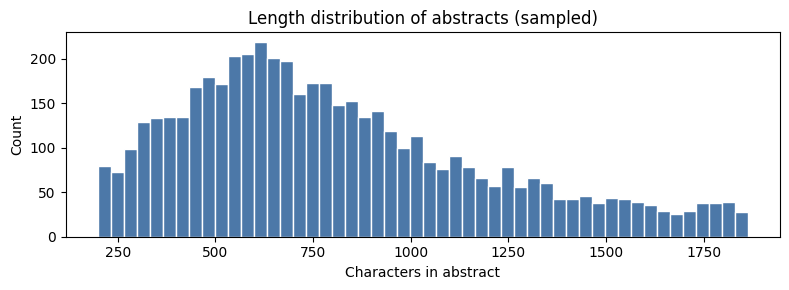

/tmp/ipykernel_55566/1729216672.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_pd["top_cat"], rotation=45, ha="right")


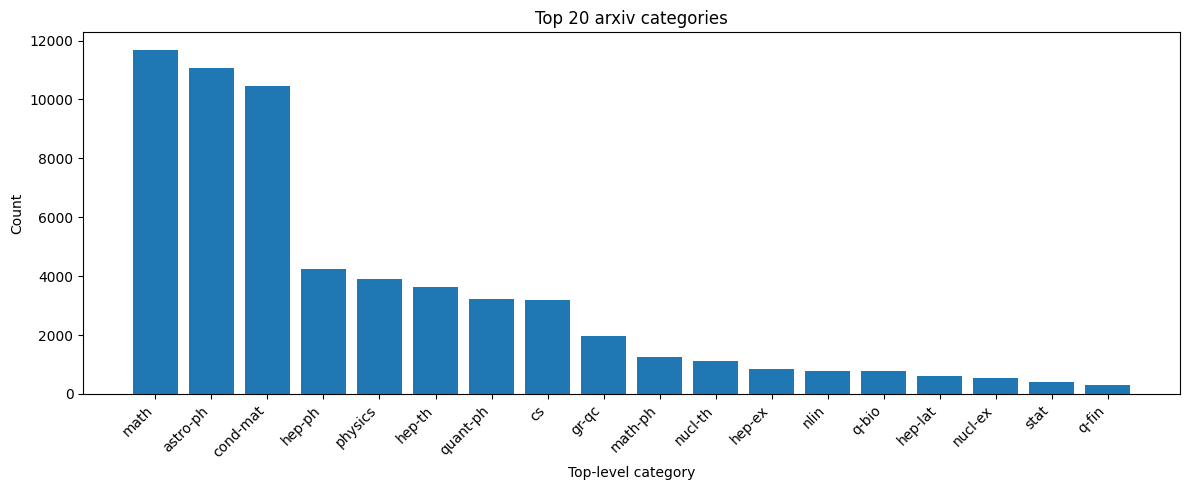

In [ ]:

# Exploratory analysis

import matplotlib.pyplot as plt
from IPython.display import display

# 1. Abstract length distribution
len_stats = (
    raw.select(F.length("abstract").alias("abstract_len"))
       .select(
           F.min("abstract_len").alias("min"),
           F.max("abstract_len").alias("max"),
           F.mean("abstract_len").alias("mean"),
           F.percentile_approx("abstract_len", 0.5).alias("median"),
       )
       .first()
)
print("Abstract length stats:", len_stats.asDict())

# histogram of abstract lengths (sampled to fit on the driver)
sample_lengths = (raw.select(F.length("abstract").alias("n"))
                     .sample(False, min(1.0, 5000 / n_abstracts), seed=RANDOM_SEED)
                     .toPandas())
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(sample_lengths["n"], bins=50, color="#4c78a8", edgecolor="white")
ax.set_xlabel("Characters in abstract")
ax.set_ylabel("Count")
ax.set_title("Length distribution of abstracts (sampled)")
fig.tight_layout()
display(fig)
plt.close(fig)


# 2. Top-level category distribution
cat_pd = (
    raw.select(F.split(F.split("categories", " ").getItem(0), r"\.").getItem(0).alias("top_cat"))
       .filter(F.col("top_cat").isNotNull())
       .groupBy("top_cat")
       .count()
       .orderBy(F.desc("count"))
       .limit(20)
       .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(cat_pd["top_cat"], cat_pd["count"])
ax.set_xlabel("Top-level category")
ax.set_ylabel("Count")
ax.set_title("Top 20 arxiv categories")
ax.set_xticklabels(cat_pd["top_cat"], rotation=45, ha="right")
fig.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
# Pipeline: Tokenizer → StopWordsRemover → HashingTF → MinHashLSHs
tokenizer = RegexTokenizer(
    inputCol="abstract",
    outputCol="tokens",
    pattern=r"\W+",
    minTokenLength=3,
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
)

hashing_tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    numFeatures=1 << 18,
    binary=True,
)

minhash_lsh = MinHashLSH(
    inputCol="tf_features",
    outputCol="hashes",
    numHashTables=NUM_HASHES,
    seed=RANDOM_SEED,
)

pipeline = Pipeline(stages=[tokenizer, remover, hashing_tf, minhash_lsh])

print("Fitting pipeline...")
model = pipeline.fit(raw)
hashed = model.transform(raw).cache()
print("Pipeline fitted. Schema:")
hashed.printSchema()
hashed.select("id", "tokens", "filtered_tokens", "hashes").show(3, truncate=60)

Fitting pipeline...
Pipeline fitted. Schema:
root
 |-- id: string (nullable = true)
 |-- abstract: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- tf_features: vector (nullable = true)
 |-- hashes: array (nullable = true)
 |    |-- element: vector (containsNull = true)

+---------+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+
|       id|                                                      tokens|                                             filtered_tokens|                                                      hashes|
+---------+------------------------------------------------------------+------------------------------------------------------------+---

Run approximate similarity join on MinHashLSH indexes, filter self-pairs and duplicates, extract candidate pairs above Jaccard threshold.

In [ ]:
# Identifying similar pairs through LSH
lsh_model = model.stages[-1]  # MinHashLSHModel is the last stage

similar_pairs = (
    lsh_model.approxSimilarityJoin(
        hashed, hashed,
        threshold=JACCARD_THRESHOLD,
        distCol="jaccard_distance",
    )
    # remove self-pairs and keep only one of (A,B) / (B,A)
    .filter(F.col("datasetA.id") < F.col("datasetB.id"))
    .select(
        F.col("datasetA.id").alias("id_a"),
        F.col("datasetB.id").alias("id_b"),
        F.col("datasetA.abstract").alias("abstract_a"),
        F.col("datasetB.abstract").alias("abstract_b"),
        (1 - F.col("jaccard_distance")).alias("jaccard_similarity"),
    )
    .orderBy(F.desc("jaccard_similarity"))
    .cache()
)

n_pairs = similar_pairs.count()
print(f"Found {n_pairs:,} similar pairs (Jaccard >= {TARGET_THRESHOLD})")
similar_pairs.show(10, truncate=80)

print(f"\n>>> Total pipeline time: {time.time() - _t_start:.1f}s <<<")

Found 203 similar pairs (Jaccard >= 0.8)
+---------+---------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+------------------+
|     id_a|     id_b|                                                                      abstract_a|                                                                      abstract_b|jaccard_similarity|
+---------+---------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+------------------+
|0711.0976|0801.1094|  We propose the Bose-Einstein condensation (BEC) and superfluidity of\nquasi...|  We propose the Bose-Einstein condensation (BEC) and superfluidity of\nquasi...|               1.0|
|0705.4660|0708.2404|  The effects of unquenching on the perturbative improvement coefficients in\...|  The effects of unquenching on the perturbat

Repeat MinHashLSH on 5-gram word shingles instead of bag-of-words to compare context-aware vs lexical similarity; validate threshold behavior.

In [ ]:
# Shingling of n-grams of words


from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType

N_GRAM = 5

@udf(returnType=ArrayType(StringType()))
def to_shingles(tokens):
    if not tokens or len(tokens) < N_GRAM:
        return tokens or []
    return [" ".join(tokens[i:i+N_GRAM]) for i in range(len(tokens) - N_GRAM + 1)]

# filtered_tokens already computed in the previous pipeline
# (inside `hashed`, the DataFrame computed from model.transform(raw))
shingled = hashed.select("id", "abstract", "filtered_tokens") \
                 .withColumn("shingles", to_shingles("filtered_tokens"))

# HashingTF again + MinHashLSH on shingle
hashing_tf_sh = HashingTF(
    inputCol="shingles",
    outputCol="tf_features",
    numFeatures=1 << 18,
    binary=True,
)
minhash_lsh_sh = MinHashLSH(
    inputCol="tf_features",
    outputCol="hashes",
    numHashTables=NUM_HASHES,
    seed=RANDOM_SEED,
)

pipeline_sh = Pipeline(stages=[hashing_tf_sh, minhash_lsh_sh])
model_sh = pipeline_sh.fit(shingled)
hashed_sh = model_sh.transform(shingled).cache()

# looking for similar couples
lsh_sh = model_sh.stages[-1]
similar_pairs_sh = (
    lsh_sh.approxSimilarityJoin(
        hashed_sh, hashed_sh,
        threshold=JACCARD_THRESHOLD,
        distCol="jaccard_distance",
    )
    .filter(F.col("datasetA.id") < F.col("datasetB.id"))
    .select(
        F.col("datasetA.id").alias("id_a"),
        F.col("datasetB.id").alias("id_b"),
        F.col("datasetA.abstract").alias("abstract_a"),
        F.col("datasetB.abstract").alias("abstract_b"),
        (1 - F.col("jaccard_distance")).alias("jaccard_similarity"),
    )
    .orderBy(F.desc("jaccard_similarity"))
)

n_pairs_sh = similar_pairs_sh.count()
print(f"bag-of-words: {n_pairs:,}")
print(f"5-shingle:    {n_pairs_sh:,}")
similar_pairs_sh.show(10, truncate=80)

bag-of-words: 203
5-shingle:    90
+---------+---------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+------------------+
|     id_a|     id_b|                                                                      abstract_a|                                                                      abstract_b|jaccard_similarity|
+---------+---------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+------------------+
|0704.3882|0710.2085|  We determine from Polyakov loop correlators the screening masses in the\nde...|  We determine from Polyakov loop correlators the screening masses in th e\nd...|               1.0|
|0706.0506|0706.0509|  We employ the Monte Carlo particle collision code DPMJET3.04 to determine t...|  We employ the Monte Carlo particle collision code